# Nomadic Intelligence — Scenario D (v2)
## Φ Variant Comparison: JSD_v2 추가 실험

**배경**: v1 실험에서 Phi_JSD/KL의 구조적 한계 확인.
- Phi_JSD (batch-mean JSD): fixation 달성 직후 g_t ≈ g_{t-1} → JSD ≈ 0 → Φ ≈ 0 → 신호 소멸
- 결과: Stable Entropy가 내려가지 않음 (0.474 vs EMA 0.297), ΔH = 0.462 < EMA 0.540

**v2 핵심 가설**: JSD가 낮은 이유는 **batch-mean을 쓰기 때문**이다.
fixated된 gate는 샘플 평균이 안정적이지만, **개별 샘플 간 routing 분산**은 여전히 nonzero.
→ `Phi_JSD_v2 = tanh(scale · std(per-sample JSD vs batch-mean))` 로 교체.
fixation 국면에서도 샘플 단위 routing confidence의 분산이 Φ를 유지 → DwellReg와 상호작용 가능.

| Variant | 수식 | 핵심 특징 |
|---|---|---|
| `Phi_EMA` | tanh(s_env·Δx + s_err·δerr + s_exp·L + s_gap·gap) | composite heuristic (v1 winner) |
| `Phi_JSD` | tanh(scale · JSD(ḡ_t ‖ ḡ_{t-1})) | batch-mean divergence → fixation 후 소멸 |
| `Phi_KL` | tanh(scale · KL(ḡ_t ‖ ḡ_{t-1})) | asymmetric, 동일 한계 |
| `Phi_Switch` | PolicyNet switch_prob | end-to-end, 포화 문제 |
| **`Phi_JSD_v2`** | **tanh(s_div · std_i[JSD(g_i ‖ ḡ_t)] + s_ema · EMA_JSD)** | **per-sample 분산 + EMA 완충** |

**Phi_JSD_v2 설계**:
```
per_jsd[i] = JSD(g_i ‖ ḡ_t)   # 개별 샘플의 routing이 배치 평균과 얼마나 다른가
phi = tanh(s_div · std(per_jsd) + s_ema · EMA(mean(per_jsd)))
```
- `std(per_jsd)`: fixation이 완성돼도 nonzero (샘플 간 routing 다양성)
- `EMA(mean(per_jsd))`: 시간적 완충, 급격한 신호 소멸 방지

**Seeds**: 42, 123, 456 | **GPU**: A100

In [ ]:
# ============================================================
# STEP 0: 환경 확인
# ============================================================
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    print(f'CUDA version: {torch.version.cuda}')


PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA L4
VRAM: 23.7 GB
CUDA version: 12.8


In [ ]:
# ============================================================
# STEP 1: Imports & Reproducibility
# ============================================================
import os
import random
import math
from abc import ABC, abstractmethod
from collections import deque
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

matplotlib.rcParams['figure.dpi'] = 120


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')


Using device: cuda


In [ ]:
# ============================================================
# STEP 2: Config
# run_structured.py 기본값과 동일하게 유지 (변경 없음)
# ============================================================
@dataclass
class Config:
    seed: int = 42
    device: str = DEVICE

    # data
    input_dim: int = 2
    output_dim: int = 1
    overlap_std: float = 0.9

    # model
    hidden_dim: int = 64
    num_experts: int = 3
    gate_hidden_dim: int = 64
    temperature: float = 0.60

    # training
    epochs: int = 220
    lr: float = 2e-3
    weight_decay: float = 1e-5

    # phase sequence
    phase_batch_size: int = 64
    phase_train_cycles: int = 40
    phase_test_cycles: int = 12
    transition_steps: int = 8

    # hybrid delta
    ema_decay: float = 0.80
    err_baseline_momentum: float = 0.85
    w_env: float = 1.0
    w_err: float = 2.0

    # loss weights
    alpha_dogma: float = 0.04
    beta_nomad: float = 0.05
    beta_phi: float = 0.05
    gamma_diversity: float = 0.08
    lambda_sep: float = 0.08
    lambda_cons: float = 0.03
    lambda_load: float = 0.03
    tau_k_min: int = 3
    tau_k_penalty: float = 0.05

    # dynamic tau
    use_dynamic_tau: bool = True
    tau_min: float = 2.0
    tau_max: float = 8.0
    tau_var_scale: float = 6.0
    tau_var_window: int = 8

    # phi / switching — used by Phi_EMA (baseline)
    phi_scale_env: float = 1.0
    phi_scale_err: float = 1.5
    phi_scale_explain: float = 2.0
    phi_scale_gap: float = 1.0

    temp_stable: float = 0.30
    temp_transition: float = 1.00

    use_hard_switch: bool = True
    phi_hard_threshold: float = 0.35

    # policy
    policy_hidden_dim: int = 64
    policy_mix_weight: float = 0.25
    policy_weight_stay: float = 0.20
    policy_weight_target: float = 0.20
    policy_weight_mode: float = 0.10
    policy_switch_threshold: float = 0.50


PHI_VARIANTS = ['Phi_EMA', 'Phi_JSD', 'Phi_KL', 'Phi_Switch', 'Phi_JSD_v2']
SEEDS = [42, 123, 456]

print('Config loaded. PHI_VARIANTS:', PHI_VARIANTS)
print('SEEDS:', SEEDS)


Config loaded. PHI_VARIANTS: ['Phi_EMA', 'Phi_JSD', 'Phi_KL', 'Phi_Switch', 'Phi_JSD_v2']
SEEDS: [42, 123, 456]


In [ ]:
# ============================================================
# STEP 3: Data Generation
# run_structured.py 동일 로직 유지
# ============================================================
REGIME_TO_ID = {'A': 0, 'B': 1, 'C': 2}
ID_TO_REGIME = {0: 'A', 1: 'B', 2: 'C'}
REGIME_ORDER = ['A', 'B', 'C']


def sample_regime_x(regime: str, n: int, std: float, device: str = 'cpu') -> torch.Tensor:
    noise = std * torch.randn(n, 2, device=device)
    centers = {'A': (2.5, 2.5), 'B': (-2.5, -2.5), 'C': (2.5, -2.5)}
    c = centers[regime]
    return noise + torch.tensor(c, device=device)


def regime_function(x: torch.Tensor, regime: str) -> torch.Tensor:
    x1, x2 = x[:, 0], x[:, 1]
    if regime == 'A': y = x1 + x2
    elif regime == 'B': y = x1 - x2
    elif regime == 'C': y = -x1 + 0.5 * x2
    else: raise ValueError(regime)
    return y.unsqueeze(-1)


def generate_phase_sequence(cfg: Config, cycles: int, device: str = 'cpu'):
    xs, ys, rs, phase_tags = [], [], [], []
    for _ in range(cycles):
        for i, curr_r in enumerate(REGIME_ORDER):
            next_r = REGIME_ORDER[(i + 1) % len(REGIME_ORDER)]
            x_s = sample_regime_x(curr_r, cfg.phase_batch_size, cfg.overlap_std, device)
            y_s = regime_function(x_s, curr_r)
            r_s = torch.full((cfg.phase_batch_size,), REGIME_TO_ID[curr_r], dtype=torch.long, device=device)
            xs.append(x_s); ys.append(y_s); rs.append(r_s)
            phase_tags.extend([f'stable_{curr_r}'] * cfg.phase_batch_size)

            for step in range(cfg.transition_steps):
                alpha = (step + 1) / cfg.transition_steps
                x_a = sample_regime_x(curr_r, cfg.phase_batch_size, cfg.overlap_std, device)
                x_b = sample_regime_x(next_r, cfg.phase_batch_size, cfg.overlap_std, device)
                x_mix = (1.0 - alpha) * x_a + alpha * x_b
                y_mix = (1.0 - alpha) * regime_function(x_mix, curr_r) + alpha * regime_function(x_mix, next_r)
                dominant = curr_r if alpha < 0.5 else next_r
                r_mix = torch.full((cfg.phase_batch_size,), REGIME_TO_ID[dominant], dtype=torch.long, device=device)
                xs.append(x_mix); ys.append(y_mix); rs.append(r_mix)
                phase_tags.extend([f'transition_{curr_r}_to_{next_r}'] * cfg.phase_batch_size)

    return torch.cat(xs), torch.cat(ys), torch.cat(rs), phase_tags


def iterate_sequence_minibatches(X, Y, R, batch_size: int):
    n = X.size(0)
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        yield X[start:end], Y[start:end], R[start:end]


print('Data utilities ready.')


Data utilities ready.


In [ ]:
# ============================================================
# STEP 4: Model Definitions
# run_structured.py 아키텍처 동일 유지
# ============================================================

class Expert(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
        )
    def forward(self, x): return self.net(x)


class GateNet(nn.Module):
    def __init__(self, input_dim, gate_hidden_dim, num_experts):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim + 2, gate_hidden_dim), nn.ReLU(),
            nn.Linear(gate_hidden_dim, gate_hidden_dim), nn.ReLU(),
            nn.Linear(gate_hidden_dim, num_experts),
        )
    def forward(self, x, delta_hybrid, delta_err, temperature):
        gate_input = torch.cat([x, delta_hybrid, delta_err], dim=-1)
        logits = self.net(gate_input)
        return F.softmax(logits / temperature, dim=-1), logits


class PolicyNet(nn.Module):
    """
    입력: x_summary(input_dim) + delta_hybrid(1) + delta_err(1)
          + phi_signal(1) + sigma2_delta_scaled(1) + dynamic_tau_scaled(1)
    출력: stay_switch_probs [B,2], target_probs [B,E], mode_probs [B,2]

    Phi_Switch variant에서는 stay_switch_probs[:,1] 자체가 Φ가 된다.
    """
    def __init__(self, input_dim, hidden_dim, num_experts):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim + 5, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
        )
        self.stay_switch_head = nn.Linear(hidden_dim, 2)
        self.target_head = nn.Linear(hidden_dim, num_experts)
        self.mode_head = nn.Linear(hidden_dim, 2)

    def forward(self, policy_input):
        h = self.shared(policy_input)
        return (
            F.softmax(self.stay_switch_head(h), dim=-1),
            F.softmax(self.target_head(h), dim=-1),
            F.softmax(self.mode_head(h), dim=-1),
        )


class NomadicMoE(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_experts,
                 gate_hidden_dim, policy_hidden_dim=64):
        super().__init__()
        self.num_experts = num_experts
        self.experts = nn.ModuleList([
            Expert(input_dim, hidden_dim, output_dim) for _ in range(num_experts)
        ])
        self.gate = GateNet(input_dim, gate_hidden_dim, num_experts)
        self.policy = PolicyNet(input_dim, policy_hidden_dim, num_experts)

    def forward(self, x, delta_hybrid, delta_err, temperature, hard=False):
        gate_probs, gate_logits = self.gate(x, delta_hybrid, delta_err, temperature)
        expert_outputs = torch.stack([e(x) for e in self.experts], dim=1)  # [B, E, 1]
        if hard:
            top1 = gate_probs.argmax(dim=-1)
            routing = F.one_hot(top1, num_classes=self.num_experts).float()
        else:
            routing = gate_probs
        y_hat = (routing.unsqueeze(-1) * expert_outputs).sum(dim=1)
        return y_hat, gate_probs, gate_logits, expert_outputs


print('Model definitions ready.')


Model definitions ready.


In [ ]:
# ============================================================
# STEP 5: PhiComputer 추상 클래스 + 4종 구현
# 핵심 설계: 동일 인터페이스, plug-in 교체 가능
# ============================================================

class PhiComputer(ABC):
    """
    Φ (switching pressure) 추상 인터페이스.
    모든 variant는 compute()를 구현해야 한다.
    반환값: scalar tensor in [0, 1] (tanh 정규화)
    """
    @abstractmethod
    def compute(
        self,
        delta_env: float,
        delta_err: float,
        explanation_error: torch.Tensor,
        best_expert_gap: torch.Tensor,
        gate_probs: torch.Tensor,
        stay_switch_probs: Optional[torch.Tensor] = None,
        cfg: Optional['Config'] = None,
    ) -> torch.Tensor:
        pass

    def reset(self):
        """시퀀스 시작 시 상태 초기화 (필요한 variant만 override)"""
        pass


class PhiEMA(PhiComputer):
    """
    φ = tanh(s_env·Δx_env + s_err·Δx_err + s_exp·L_task + s_gap·gap_t)
    run_structured.py 현재 구현과 동일 — baseline.
    """
    def compute(self, delta_env, delta_err, explanation_error, best_expert_gap,
                gate_probs, stay_switch_probs=None, cfg=None):
        device = explanation_error.device
        env_term     = cfg.phi_scale_env     * torch.tensor(delta_env,  device=device)
        err_term     = cfg.phi_scale_err     * torch.tensor(delta_err,  device=device)
        explain_term = cfg.phi_scale_explain * explanation_error.detach()
        gap_term     = cfg.phi_scale_gap     * best_expert_gap.detach()
        return torch.tanh(env_term + err_term + explain_term + gap_term)


class PhiJSD(PhiComputer):
    """
    φ = tanh(scale · JSD(g_t ‖ g_{t-1}))
    JSD ∈ [0, log2], log2로 normalize → [0,1] 후 tanh scaling.
    """
    def __init__(self, scale: float = 4.0, eps: float = 1e-8):
        self.scale = scale
        self.eps = eps
        self.prev_gate: Optional[torch.Tensor] = None

    def reset(self):
        self.prev_gate = None

    def compute(self, delta_env, delta_err, explanation_error, best_expert_gap,
                gate_probs, stay_switch_probs=None, cfg=None):
        device = gate_probs.device
        curr = gate_probs.mean(dim=0)
        if self.prev_gate is None:
            self.prev_gate = curr.detach()
            return torch.tensor(0.0, device=device)
        P, Q = curr, self.prev_gate.detach()
        M = 0.5 * (P + Q)
        kl_pm = (P * (torch.log(P + self.eps) - torch.log(M + self.eps))).sum()
        kl_qm = (Q * (torch.log(Q + self.eps) - torch.log(M + self.eps))).sum()
        jsd_norm = (0.5 * kl_pm + 0.5 * kl_qm) / math.log(2)
        self.prev_gate = curr.detach()
        return torch.tanh(self.scale * jsd_norm)


class PhiKL(PhiComputer):
    """
    φ = tanh(scale · KL(g_t ‖ g_{t-1}))
    asymmetric: fixation→switch 순간에 JSD보다 예민하게 반응.
    """
    def __init__(self, scale: float = 3.0, eps: float = 1e-8):
        self.scale = scale
        self.eps = eps
        self.prev_gate: Optional[torch.Tensor] = None

    def reset(self):
        self.prev_gate = None

    def compute(self, delta_env, delta_err, explanation_error, best_expert_gap,
                gate_probs, stay_switch_probs=None, cfg=None):
        device = gate_probs.device
        curr = gate_probs.mean(dim=0)
        if self.prev_gate is None:
            self.prev_gate = curr.detach()
            return torch.tensor(0.0, device=device)
        P, Q = curr, self.prev_gate.detach()
        kl = torch.clamp(
            (P * (torch.log(P + self.eps) - torch.log(Q + self.eps))).sum(),
            min=0.0
        )
        self.prev_gate = curr.detach()
        return torch.tanh(self.scale * kl)


class PhiSwitch(PhiComputer):
    """
    φ = stay_switch_probs[:, 1].mean()
    PolicyNet의 switch head를 Φ로 직접 사용 — end-to-end learned.
    """
    def __init__(self, warm_start_phi: float = 0.3):
        self.warm_start_phi = warm_start_phi

    def compute(self, delta_env, delta_err, explanation_error, best_expert_gap,
                gate_probs, stay_switch_probs=None, cfg=None):
        device = gate_probs.device
        if stay_switch_probs is None:
            return torch.tensor(self.warm_start_phi, device=device)
        return stay_switch_probs[:, 1].mean().detach()


class PhiJSD_v2(PhiComputer):
    """
    Φ = tanh(s_div · std_i[JSD(g_i ‖ ḡ_t)] + s_ema · EMA_mean_jsd)

    v1 JSD의 구조적 한계 수정:
      v1: JSD(batch-mean_t ‖ batch-mean_{t-1}) → fixation 후 ≈ 0
      v2: 개별 샘플의 routing이 배치 평균과 얼마나 흩어져있는가 (intra-batch diversity)

    두 항:
      std_term  = std over i of JSD(g_i ‖ ḡ_t)
                  → fixation이 완성돼도 샘플 간 routing 다양성이 있으면 nonzero
                  → routing이 완전히 collapse되면 → 0 (올바른 fixation 감지)
      ema_term  = EMA of mean over i of JSD(g_i ‖ ḡ_t)
                  → 시간적 smooth: 갑작스러운 신호 소멸 방지

    결합: phi = tanh(s_div * std_term + s_ema * ema_term)
      s_div > s_ema 권장: std_term이 주 신호, ema_term은 완충

    이론적 해석:
      JSD(g_i ‖ ḡ_t) = 개별 라우팅의 '평균으로부터의 정보 거리'
      std(JSD_i) = 라우팅 confidence의 heterogeneity
      이 값이 높으면 같은 배치 내에서도 expert 선택이 불안정 → switching pressure 있음
      이 값이 낮으면 모든 샘플이 동일한 expert를 선택 = true fixation
    """
    def __init__(self, s_div: float = 8.0, s_ema: float = 3.0,
                 ema_decay: float = 0.85, eps: float = 1e-8):
        self.s_div = s_div
        self.s_ema = s_ema
        self.ema_decay = ema_decay
        self.eps = eps
        self.ema_mean_jsd: Optional[float] = None  # running EMA of mean(per_jsd)

    def reset(self):
        self.ema_mean_jsd = None

    def _per_sample_jsd(self, gate_probs: torch.Tensor) -> torch.Tensor:
        """
        gate_probs: [B, E]
        batch_mean: [E]  → broadcast to [B, E]
        Returns per_jsd: [B] — JSD between each sample and batch mean
        """
        batch_mean = gate_probs.mean(dim=0, keepdim=True)  # [1, E]
        P = gate_probs          # [B, E]
        Q = batch_mean.expand_as(P)  # [B, E]
        M = 0.5 * (P + Q)            # [B, E]

        kl_pm = (P * (torch.log(P + self.eps) - torch.log(M + self.eps))).sum(dim=-1)  # [B]
        kl_qm = (Q * (torch.log(Q + self.eps) - torch.log(M + self.eps))).sum(dim=-1)  # [B]
        jsd = (0.5 * kl_pm + 0.5 * kl_qm).clamp(min=0.0) / math.log(2)  # [B], ∈ [0,1]
        return jsd

    def compute(self, delta_env, delta_err, explanation_error, best_expert_gap,
                gate_probs, stay_switch_probs=None, cfg=None):
        device = gate_probs.device

        per_jsd = self._per_sample_jsd(gate_probs)   # [B]
        std_term  = float(per_jsd.std().item())       # scalar
        mean_term = float(per_jsd.mean().item())      # scalar

        # EMA 업데이트
        if self.ema_mean_jsd is None:
            self.ema_mean_jsd = mean_term
        else:
            self.ema_mean_jsd = (self.ema_decay * self.ema_mean_jsd
                                 + (1.0 - self.ema_decay) * mean_term)

        phi_raw = self.s_div * std_term + self.s_ema * self.ema_mean_jsd
        return torch.tanh(torch.tensor(phi_raw, device=device))


def make_phi(name: str) -> PhiComputer:
    return {'Phi_EMA':    PhiEMA,
            'Phi_JSD':    PhiJSD,
            'Phi_KL':     PhiKL,
            'Phi_Switch': PhiSwitch,
            'Phi_JSD_v2': PhiJSD_v2}[name]()


print('PhiComputer variants ready:', PHI_VARIANTS)


PhiComputer variants ready: ['Phi_EMA', 'Phi_JSD', 'Phi_KL', 'Phi_Switch', 'Phi_JSD_v2']


In [ ]:
# ============================================================
# STEP 6: Utilities
# run_structured.py와 동일. 최적화: load_balancing bincount 벡터화
# ============================================================

class HybridDeltaTracker:
    def __init__(self, cfg: Config, device: str):
        self.cfg = cfg
        self.device = device
        self.prev_x_mean = None
        self.err_ema = None
        self.err_baseline = None
        self.recent_delta_env = deque(maxlen=cfg.tau_var_window)

    def reset(self):
        self.prev_x_mean = None
        self.err_ema = None
        self.err_baseline = None
        self.recent_delta_env.clear()

    def compute_dynamic_tau(self, sigma2_delta: float) -> float:
        tau = self.cfg.tau_min + (self.cfg.tau_max - self.cfg.tau_min) / (
            1.0 + self.cfg.tau_var_scale * sigma2_delta)
        return float(np.clip(tau, self.cfg.tau_min, self.cfg.tau_max))

    def compute(self, x: torch.Tensor, batch_mse: torch.Tensor):
        x_mean = x.mean(dim=0, keepdim=True)
        if self.prev_x_mean is None:
            delta_env_scalar = torch.tensor(0.0, device=self.device)
        else:
            delta_env_scalar = torch.norm(x_mean - self.prev_x_mean, p=2)

        batch_err = batch_mse.detach()
        if self.err_ema is None:
            self.err_ema = batch_err
            self.err_baseline = batch_err
            delta_err_scalar = torch.tensor(0.0, device=self.device)
        else:
            self.err_ema = (self.cfg.ema_decay * self.err_ema
                            + (1 - self.cfg.ema_decay) * batch_err)
            self.err_baseline = (self.cfg.err_baseline_momentum * self.err_baseline
                                 + (1 - self.cfg.err_baseline_momentum) * self.err_ema)
            delta_err_scalar = torch.relu(self.err_ema - self.err_baseline)

        raw = self.cfg.w_env * delta_env_scalar + self.cfg.w_err * delta_err_scalar
        delta_hybrid = torch.tanh(raw)
        self.prev_x_mean = x_mean.detach()

        de   = float(delta_env_scalar.item())
        derr = float(delta_err_scalar.item())
        dh   = float(delta_hybrid.item())

        self.recent_delta_env.append(de)
        sigma2 = float(np.var(self.recent_delta_env)) if len(self.recent_delta_env) >= 2 else 0.0
        dynamic_tau = self.compute_dynamic_tau(sigma2)

        delta_hybrid_t = torch.full((x.size(0), 1), dh,   device=self.device)
        delta_err_t    = torch.full((x.size(0), 1), derr, device=self.device)
        return delta_hybrid_t, delta_err_t, de, derr, dh, sigma2, dynamic_tau


class DwellTimeRegularizer:
    def __init__(self, tau_k_min: int = 3, penalty: float = 0.05):
        self.tau_k_min = tau_k_min
        self.penalty = penalty
        self.current_expert = None
        self.dwell_count = 0

    def reset(self):
        self.current_expert = None
        self.dwell_count = 0

    def compute(self, gate_probs: torch.Tensor, tau_dynamic: float = None) -> torch.Tensor:
        dominant = int(torch.bincount(
            gate_probs.argmax(dim=-1), minlength=gate_probs.size(-1)
        ).argmax().item())
        if dominant == self.current_expert:
            self.dwell_count += 1
        else:
            self.current_expert = dominant
            self.dwell_count = 1
        eps = 1e-8
        entropy = -(gate_probs * (gate_probs + eps).log()).sum(dim=-1).mean()
        tau_cap = float(tau_dynamic if tau_dynamic is not None else self.tau_k_min)
        if self.dwell_count <= tau_cap:
            return -self.penalty * entropy
        else:
            excess = self.dwell_count - tau_cap
            bw = min(float(excess) * self.penalty, self.penalty * 10)
            return bw * entropy


def gate_entropy(gate_probs: torch.Tensor) -> torch.Tensor:
    eps = 1e-8
    return -(gate_probs * (gate_probs + eps).log()).sum(dim=-1)


# [최적화] Python for loop → bincount 벡터화: GPU↔CPU 동기화 제거
def compute_load_balancing_loss(gate_probs: torch.Tensor) -> torch.Tensor:
    K = gate_probs.size(-1)
    mean_gate = gate_probs.mean(dim=0)
    top1 = gate_probs.argmax(dim=-1)
    top1_frac = torch.bincount(top1, minlength=K).float() / top1.size(0)
    return K * (top1_frac * mean_gate).sum()


def compute_dogma_penalty(gate_probs: torch.Tensor) -> torch.Tensor:
    mean_usage = gate_probs.mean(dim=0)
    return torch.sum(mean_usage ** 2) - 1.0 / gate_probs.size(1)


def compute_nomad_bonus(gate_probs: torch.Tensor) -> torch.Tensor:
    eps = 1e-8
    return -(gate_probs * (gate_probs + eps).log()).sum(dim=-1).mean()


def compute_diversity_loss(expert_outputs: torch.Tensor) -> torch.Tensor:
    K = expert_outputs.size(1)
    if K < 2:
        return torch.tensor(0.0, device=expert_outputs.device)
    loss = 0.0; count = 0
    for i in range(K):
        for j in range(i + 1, K):
            loss += F.cosine_similarity(
                expert_outputs[:, i], expert_outputs[:, j], dim=-1
            ).mean()
            count += 1
    return loss / count


def compute_explanation_signals(y_true, y_hat, expert_outputs, gate_probs):
    explanation_error = F.mse_loss(y_hat, y_true)
    per_expert_sqerr = ((expert_outputs - y_true.unsqueeze(1)) ** 2).mean(dim=-1)
    top1_idx = gate_probs.argmax(dim=-1)
    top1_err = per_expert_sqerr.gather(1, top1_idx.unsqueeze(1)).mean()
    best_expert_err = per_expert_sqerr.min(dim=1).values.mean()
    return explanation_error, torch.relu(top1_err - best_expert_err)


def compute_regime_gate_stats(gate_probs, regime_ids, num_regimes=3):
    device = gate_probs.device
    valid_means, valid_names = [], []
    l_cons = torch.tensor(0.0, device=device)
    cnt = 0
    for rid in range(num_regimes):
        mask = regime_ids == rid
        if mask.sum() == 0:
            continue
        g_r = gate_probs[mask]; u_r = g_r.mean(dim=0)
        valid_means.append(u_r); valid_names.append(ID_TO_REGIME[rid])
        l_cons = l_cons + ((g_r - u_r.unsqueeze(0)) ** 2).sum(dim=-1).mean()
        cnt += 1
    if cnt > 0:
        l_cons = l_cons / cnt
    if len(valid_means) < 2:
        return torch.tensor(0.0, device=device), l_cons
    pairwise = [torch.norm(valid_means[i] - valid_means[j], p=2)
                for i in range(len(valid_means))
                for j in range(i + 1, len(valid_means))]
    l_sep = -torch.stack(pairwise).mean()
    return l_sep, l_cons


def regimewise_usage(gate_probs, regime_ids, num_experts):
    usage = {}
    top1 = gate_probs.argmax(dim=-1)
    for rid in range(3):
        mask = regime_ids == rid
        name = ID_TO_REGIME[rid]
        if mask.sum() == 0:
            usage[name] = np.zeros(num_experts)
        else:
            counts = torch.bincount(top1[mask], minlength=num_experts).float()
            usage[name] = (counts / counts.sum().clamp_min(1.0)).cpu().numpy()
    return usage


def compute_dwell_times(top1_sequence):
    dwells = []; current = top1_sequence[0]; run_len = 1
    for t in range(1, len(top1_sequence)):
        if top1_sequence[t] == current:
            run_len += 1
        else:
            dwells.append(run_len); current = top1_sequence[t]; run_len = 1
    dwells.append(run_len)
    return dwells


def compute_switch_latency(regime_seq, top1_seq, regime_to_expert):
    latencies = []; prev = regime_seq[0] if regime_seq else None
    for t in range(1, len(regime_seq)):
        curr = regime_seq[t]
        if curr != prev:
            target = regime_to_expert.get(curr)
            if target is not None:
                for k in range(t, len(top1_seq)):
                    if int(top1_seq[k]) == int(target):
                        latencies.append(k - t)
                        break
        prev = curr
    return latencies


def build_policy_input(xb, delta_hybrid, delta_err_t, phi_signal, sigma2_delta, dynamic_tau):
    x_summary = xb.mean(dim=0, keepdim=True).expand(xb.size(0), -1)
    phi_t    = torch.full((xb.size(0), 1), float(phi_signal.mean().item()), device=xb.device)
    sigma2_t = torch.full((xb.size(0), 1), float(np.tanh(sigma2_delta * 10.0)), device=xb.device)
    tau_t    = torch.full((xb.size(0), 1), float(np.tanh((dynamic_tau - 5.0) / 5.0)), device=xb.device)
    return torch.cat([x_summary, delta_hybrid, delta_err_t, phi_t, sigma2_t, tau_t], dim=-1)


def build_policy_targets(y_true, expert_outputs, phi_signal, sigma2_delta, dynamic_tau,
                          switch_threshold, tau_stay_threshold=5.5, sigma_switch_threshold=0.05):
    per_expert_sqerr = ((expert_outputs - y_true.unsqueeze(1)) ** 2).mean(dim=-1)
    target_expert = per_expert_sqerr.mean(dim=0).argmin().long()
    phi_val = float(phi_signal.mean().item())
    should_switch = (phi_val > switch_threshold) or (sigma2_delta > sigma_switch_threshold)
    can_fixate    = (phi_val <= switch_threshold) and (dynamic_tau >= tau_stay_threshold)
    return (1 if should_switch else 0), target_expert, (1 if can_fixate else 0)


print('Utilities ready.')


Utilities ready.


In [ ]:
# ============================================================
# STEP 7: 통합 학습 함수 — phi_variant를 인자로 받음
#
# [최적화 1] warm pass + probe pass 통합 → forward 3회 → 2회
#   - 원본: zero_delta warm pass (MSE 추정) + delta probe pass (explanation signal)
#   - 수정: zero_delta로 한번에 warm_mse + explanation signal 동시 획득
#   - 수학적 동등성: probe pass의 explanation signal은 delta signal의 정밀도보다
#     phi 계산의 방향성(sign)이 중요하므로 zero_delta 근사는 충분히 유효함.
#     실제 delta는 warm_mse로부터 계산되고, 이 근사는 원본 코드와 동일한 수준.
#
# [최적화 2] tracker / dwell_reg epoch마다 재생성 → 루프 밖에서 한번 생성 후 reset만
#   - 객체 생성 비용 제거. reset()은 상태만 초기화하므로 동작 동일.
# ============================================================

def train_nomadic_phi_variant(
    cfg: Config,
    X_train, Y_train, R_train,
    X_test, Y_test, R_test,
    phase_tags_test: List[str],
    phi_computer: PhiComputer,
    phi_name: str,
    verbose: bool = True,
):
    model = NomadicMoE(
        input_dim=cfg.input_dim, hidden_dim=cfg.hidden_dim,
        output_dim=cfg.output_dim, num_experts=cfg.num_experts,
        gate_hidden_dim=cfg.gate_hidden_dim, policy_hidden_dim=cfg.policy_hidden_dim,
    ).to(cfg.device)

    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    logs = {
        'train_mse': [], 'train_total': [],
        'test_seq_mse': [],
        'test_stable_entropy': [], 'test_transition_entropy': [],
        'test_switch_latency': [],
        'phi_values': [],
        'dynamic_tau': [],
        'policy_switch_rate': [],
    }

    # [최적화] 루프 밖에서 한번만 생성
    tracker  = HybridDeltaTracker(cfg=cfg, device=cfg.device)
    dwell_reg = DwellTimeRegularizer(tau_k_min=cfg.tau_k_min, penalty=cfg.tau_k_penalty)

    for epoch in range(cfg.epochs):
        model.train()
        phi_computer.reset()
        tracker.reset()    # 생성 대신 reset만
        dwell_reg.reset()

        epoch_mse = epoch_total = 0.0
        epoch_phi_vals = []
        epoch_switch_rate = 0.0
        n_batches = 0

        for xb, yb, rb in iterate_sequence_minibatches(X_train, Y_train, R_train, cfg.phase_batch_size):
            optimizer.zero_grad()

            # [최적화] warm pass + probe pass 통합:
            # zero_delta로 한번에 warm_mse + explanation signal 획득
            with torch.no_grad():
                z = torch.zeros((xb.size(0), 1), device=cfg.device)
                probe_y, probe_gate, _, probe_experts = model(xb, z, z, cfg.temperature)
                warm_mse = F.mse_loss(probe_y, yb)

            delta_hybrid_t, delta_err_t, de, derr, dh, sigma2, dyn_tau = tracker.compute(xb, warm_mse)
            expl_err, gap = compute_explanation_signals(yb, probe_y, probe_experts, probe_gate)

            # Phi provisional (Phi_Switch는 아래에서 재계산)
            phi_provisional = phi_computer.compute(
                delta_env=de, delta_err=derr,
                explanation_error=expl_err, best_expert_gap=gap,
                gate_probs=probe_gate, stay_switch_probs=None, cfg=cfg,
            )

            # PolicyNet forward
            policy_input = build_policy_input(
                xb, delta_hybrid_t, delta_err_t, phi_provisional, sigma2, dyn_tau
            )
            stay_switch_probs, target_probs, mode_probs = model.policy(policy_input)

            # Phi_Switch: stay_switch_probs 받은 후 phi 재계산
            if phi_name == 'Phi_Switch':
                phi_signal = phi_computer.compute(
                    delta_env=de, delta_err=derr,
                    explanation_error=expl_err, best_expert_gap=gap,
                    gate_probs=probe_gate, stay_switch_probs=stay_switch_probs, cfg=cfg,
                )
            else:
                phi_signal = phi_provisional

            phi_val = float(phi_signal.item() if phi_signal.dim() == 0 else phi_signal.mean().item())
            epoch_phi_vals.append(phi_val)

            temp_now = cfg.temp_stable + (cfg.temp_transition - cfg.temp_stable) * phi_val
            failsafe_soft = dh > cfg.phi_hard_threshold
            hard_mode = (
                cfg.use_hard_switch
                and (mode_probs[:, 1].mean().item() > 0.5)
                and not failsafe_soft
            )

            # main forward (with grad)
            y_hat, gate_probs, _, expert_outputs = model(
                xb, delta_hybrid_t, delta_err_t, temp_now, hard=False
            )

            # PolicyNet mixing (STE)
            effective_mix = cfg.policy_mix_weight * float(stay_switch_probs[:, 1].mean().item())
            target_idx = torch.argmax(target_probs.mean(dim=0), dim=-1)
            target_onehot_hard = (F.one_hot(target_idx, num_classes=cfg.num_experts)
                                   .float().unsqueeze(0).expand(xb.size(0), -1))
            target_onehot_ste = (target_onehot_hard - gate_probs).detach() + gate_probs
            mixed_routing = (1.0 - effective_mix) * gate_probs + effective_mix * target_onehot_ste

            if hard_mode:
                top1 = mixed_routing.argmax(dim=-1)
                final_routing = F.one_hot(top1, num_classes=cfg.num_experts).float()
            else:
                final_routing = mixed_routing

            y_hat = (final_routing.unsqueeze(-1) * expert_outputs).sum(dim=1)

            # losses
            mse_loss = F.mse_loss(y_hat, yb)
            _, gap_loss = compute_explanation_signals(yb, y_hat, expert_outputs, final_routing)

            phi_t = phi_signal if phi_signal.dim() > 0 else phi_signal.unsqueeze(0)
            cond_gap    = phi_t.detach().mean() * gap_loss
            dogma_pen   = compute_dogma_penalty(final_routing)
            nomad_bonus = compute_nomad_bonus(final_routing)
            l_sep, l_cons = compute_regime_gate_stats(final_routing, rb)
            load_loss   = compute_load_balancing_loss(final_routing)
            div_loss    = compute_diversity_loss(expert_outputs)
            dwell_bonus = dwell_reg.compute(
                final_routing,
                tau_dynamic=dyn_tau if cfg.use_dynamic_tau else float(cfg.tau_k_min)
            )

            switch_lbl, tgt_expert, mode_lbl = build_policy_targets(
                yb, probe_experts, phi_signal, sigma2, dyn_tau, cfg.policy_switch_threshold
            )
            stay_t = torch.full((xb.size(0),), switch_lbl, dtype=torch.long, device=cfg.device)
            tgt_t  = torch.full((xb.size(0),), int(tgt_expert.item()), dtype=torch.long, device=cfg.device)
            mode_t = torch.full((xb.size(0),), mode_lbl, dtype=torch.long, device=cfg.device)

            stay_loss = F.nll_loss(torch.log(stay_switch_probs + 1e-8), stay_t)
            tgt_loss  = F.nll_loss(torch.log(target_probs      + 1e-8), tgt_t)
            mode_loss = F.nll_loss(torch.log(mode_probs        + 1e-8), mode_t)

            total_loss = (
                mse_loss
                + cfg.beta_phi        * cond_gap
                + cfg.alpha_dogma     * dogma_pen
                - cfg.beta_nomad      * nomad_bonus
                + cfg.gamma_diversity * div_loss
                + cfg.lambda_sep      * l_sep
                + cfg.lambda_cons     * l_cons
                + cfg.lambda_load     * load_loss
                + cfg.policy_weight_stay   * stay_loss
                + cfg.policy_weight_target * tgt_loss
                + cfg.policy_weight_mode   * mode_loss
                - dwell_bonus
            )

            total_loss.backward()
            optimizer.step()

            epoch_mse         += mse_loss.item()
            epoch_total       += total_loss.item()
            epoch_switch_rate += float(stay_switch_probs[:, 1].mean().item())
            n_batches         += 1

        logs['train_mse'].append(epoch_mse   / max(n_batches, 1))
        logs['train_total'].append(epoch_total / max(n_batches, 1))
        logs['phi_values'].append(float(np.mean(epoch_phi_vals)) if epoch_phi_vals else 0.0)
        logs['dynamic_tau'].append(0.0)
        logs['policy_switch_rate'].append(epoch_switch_rate / max(n_batches, 1))

        seq_mse, stable_ent, trans_ent, sw_lat = evaluate_sequence(
            model, X_test, Y_test, R_test, phase_tags_test, cfg, phi_computer, phi_name
        )
        logs['test_seq_mse'].append(seq_mse)
        logs['test_stable_entropy'].append(stable_ent)
        logs['test_transition_entropy'].append(trans_ent)
        logs['test_switch_latency'].append(sw_lat)

        if verbose and ((epoch + 1) % 25 == 0 or epoch == 0):
            delta_h = trans_ent - stable_ent
            print(
                f'[{phi_name}] Epoch {epoch+1:03d}/{cfg.epochs} | '
                f'Train MSE: {logs["train_mse"][-1]:.4f} | '
                f'Seq MSE: {seq_mse:.4f} | '
                f'ΔH: {delta_h:+.4f} (t:{trans_ent:.3f} s:{stable_ent:.3f}) | '
                f'Lat: {sw_lat:.3f} | '
                f'Φ̄: {logs["phi_values"][-1]:.3f} | '
                f'SwitchRate: {logs["policy_switch_rate"][-1]:.3f}'
            )

    return model, logs


def evaluate_sequence(model, X, Y, R, phase_tags, cfg, phi_computer, phi_name):
    model.eval()
    phi_computer.reset()
    tracker = HybridDeltaTracker(cfg=cfg, device=cfg.device)
    tracker.reset()

    all_y, all_gate, batch_tags, batch_ents, batch_top1 = [], [], [], [], []

    with torch.no_grad():
        for batch_idx, (xb, yb, rb) in enumerate(
            iterate_sequence_minibatches(X, Y, R, cfg.phase_batch_size)
        ):
            z = torch.zeros((xb.size(0), 1), device=cfg.device)
            probe_y, probe_gate, _, probe_experts = model(xb, z, z, cfg.temperature)
            warm_mse = F.mse_loss(probe_y, yb)

            delta_hybrid_t, delta_err_t, de, derr, dh, sigma2, dyn_tau = tracker.compute(xb, warm_mse)
            expl_err, gap = compute_explanation_signals(yb, probe_y, probe_experts, probe_gate)

            phi_provisional = phi_computer.compute(
                delta_env=de, delta_err=derr,
                explanation_error=expl_err, best_expert_gap=gap,
                gate_probs=probe_gate, stay_switch_probs=None, cfg=cfg,
            )
            if phi_name == 'Phi_Switch':
                policy_input = build_policy_input(
                    xb, delta_hybrid_t, delta_err_t, phi_provisional, sigma2, dyn_tau
                )
                ss_probs, _, _ = model.policy(policy_input)
                phi_signal = phi_computer.compute(
                    delta_env=de, delta_err=derr,
                    explanation_error=expl_err, best_expert_gap=gap,
                    gate_probs=probe_gate, stay_switch_probs=ss_probs, cfg=cfg,
                )
            else:
                phi_signal = phi_provisional

            phi_val = float(phi_signal.item() if phi_signal.dim() == 0 else phi_signal.mean().item())
            temp_now = cfg.temp_stable + (cfg.temp_transition - cfg.temp_stable) * phi_val

            y_hat, gate_probs, _, _ = model(xb, delta_hybrid_t, delta_err_t, temp_now)
            all_y.append(y_hat); all_gate.append(gate_probs)

            tag = phase_tags[batch_idx * cfg.phase_batch_size]
            batch_tags.append(tag)
            batch_ents.append(gate_entropy(gate_probs).mean().item())
            top1 = gate_probs.argmax(dim=-1)
            batch_top1.append(int(torch.bincount(top1, minlength=cfg.num_experts).argmax().item()))

    Y_hat = torch.cat(all_y); G = torch.cat(all_gate)
    seq_mse = F.mse_loss(Y_hat, Y).item()

    stable_ent = (np.mean([e for t, e in zip(batch_tags, batch_ents) if t.startswith('stable_')])
                  if any(t.startswith('stable_') for t in batch_tags) else float('nan'))
    trans_ent  = (np.mean([e for t, e in zip(batch_tags, batch_ents) if t.startswith('transition_')])
                  if any(t.startswith('transition_') for t in batch_tags) else float('nan'))

    usage = regimewise_usage(G, R, cfg.num_experts)
    r2e = {r: int(np.argmax(usage[r])) for r in ['A', 'B', 'C']}
    regime_seq = [ID_TO_REGIME[int(rb[0].item())]
                  for _, _, rb in iterate_sequence_minibatches(X, Y, R, cfg.phase_batch_size)]
    latencies = compute_switch_latency(regime_seq, np.array(batch_top1), r2e)
    sw_lat = float(np.mean(latencies)) if latencies else float('nan')

    return seq_mse, float(stable_ent), float(trans_ent), sw_lat


print('Training function ready.')


Training function ready.


In [ ]:
# ============================================================
# STEP 8: 실험 실행 (전체 4 variants × 3 seeds)
#
# [최적화] 데이터셋 사전 생성 및 재사용:
#   원본: variant × seed 루프마다 generate_phase_sequence() 호출 (12회)
#   수정: seed별로 한번만 생성 (3회), variant 루프에서 동일 데이터 재사용
#   → 동일한 seed에서 동일한 데이터이므로 실험 결과 완전히 동일
# ============================================================
import time

# seed별 데이터 사전 생성
print('Generating datasets...')
datasets = {}
for seed in SEEDS:
    set_seed(seed)
    cfg_tmp = Config(seed=seed, device=DEVICE)
    datasets[seed] = {
        'train': generate_phase_sequence(cfg_tmp, cfg_tmp.phase_train_cycles, cfg_tmp.device),
        'test':  generate_phase_sequence(cfg_tmp, cfg_tmp.phase_test_cycles,  cfg_tmp.device),
    }
    print(f'  seed {seed}: train {datasets[seed]["train"][0].shape}, test {datasets[seed]["test"][0].shape}')
print('Datasets ready.\n')

all_results = {}  # {phi_name: {seed: logs}}

total_start = time.time()

for phi_name in PHI_VARIANTS:
    all_results[phi_name] = {}
    print(f'\n{"="*60}')
    print(f'  Variant: {phi_name}')
    print(f'{"="*60}')

    for seed in SEEDS:
        print(f'\n--- Seed {seed} ---')
        set_seed(seed)
        cfg = Config(seed=seed, device=DEVICE)

        X_train, Y_train, R_train, tags_train = datasets[seed]['train']
        X_test,  Y_test,  R_test,  tags_test  = datasets[seed]['test']

        phi_computer = make_phi(phi_name)

        t0 = time.time()
        _, logs = train_nomadic_phi_variant(
            cfg=cfg,
            X_train=X_train, Y_train=Y_train, R_train=R_train,
            X_test=X_test,   Y_test=Y_test,   R_test=R_test,
            phase_tags_test=tags_test,
            phi_computer=phi_computer,
            phi_name=phi_name,
            verbose=True,
        )
        elapsed = time.time() - t0
        print(f'  → Seed {seed} done in {elapsed/60:.1f} min')
        all_results[phi_name][seed] = logs

total_elapsed = time.time() - total_start
print(f'\n\n✅ 모든 실험 완료. 총 소요시간: {total_elapsed/60:.1f} min')


Generating datasets...
  seed 42: train torch.Size([69120, 2]), test torch.Size([20736, 2])
  seed 123: train torch.Size([69120, 2]), test torch.Size([20736, 2])
  seed 456: train torch.Size([69120, 2]), test torch.Size([20736, 2])
Datasets ready.


  Variant: Phi_EMA

--- Seed 42 ---
[Phi_EMA] Epoch 001/220 | Train MSE: 0.9992 | Seq MSE: 0.4672 | ΔH: +0.3093 (t:0.919 s:0.610) | Lat: 1.028 | Φ̄: 0.971 | SwitchRate: 0.989
[Phi_EMA] Epoch 025/220 | Train MSE: 0.3114 | Seq MSE: 0.3035 | ΔH: +0.5002 (t:0.856 s:0.355) | Lat: 0.000 | Φ̄: 0.924 | SwitchRate: 0.973
[Phi_EMA] Epoch 050/220 | Train MSE: 0.1952 | Seq MSE: 0.2853 | ΔH: +0.5243 (t:0.870 s:0.346) | Lat: 0.306 | Φ̄: 0.893 | SwitchRate: 0.960
[Phi_EMA] Epoch 075/220 | Train MSE: 0.1917 | Seq MSE: 0.2915 | ΔH: +0.5018 (t:0.847 s:0.345) | Lat: 0.111 | Φ̄: 0.894 | SwitchRate: 0.960
[Phi_EMA] Epoch 100/220 | Train MSE: 0.1845 | Seq MSE: 0.2972 | ΔH: +0.4628 (t:0.851 s:0.388) | Lat: 0.389 | Φ̄: 0.892 | SwitchRate: 0.949
[Phi_EMA] Epoch 125

In [ ]:
# ============================================================
# STEP 9: 결과 집계 — 3-seed 평균/표준편차
# ============================================================

summary_rows = []

for phi_name in PHI_VARIANTS:
    seed_seq_mse, seed_delta_h, seed_latency, seed_stable, seed_trans = [], [], [], [], []
    for seed in SEEDS:
        logs = all_results[phi_name][seed]
        final_seq_mse = logs['test_seq_mse'][-1]
        final_stable  = logs['test_stable_entropy'][-1]
        final_trans   = logs['test_transition_entropy'][-1]
        final_lat     = logs['test_switch_latency'][-1]
        delta_h = final_trans - final_stable

        seed_seq_mse.append(final_seq_mse)
        seed_delta_h.append(delta_h)
        seed_latency.append(final_lat if not math.isnan(final_lat) else 0.0)
        seed_stable.append(final_stable)
        seed_trans.append(final_trans)

    summary_rows.append({
        'Phi Variant':      phi_name,
        'Seq MSE (mean)':   np.mean(seed_seq_mse),
        'Seq MSE (std)':    np.std(seed_seq_mse),
        'ΔH (mean)':        np.mean(seed_delta_h),
        'ΔH (std)':         np.std(seed_delta_h),
        'Stable Ent (mean)':np.mean(seed_stable),
        'Trans Ent (mean)': np.mean(seed_trans),
        'Switch Lat (mean)':np.mean(seed_latency),
    })

df = pd.DataFrame(summary_rows).set_index('Phi Variant')

print('\n' + '='*72)
print('SCENARIO D: Φ Variant Comparison (avg over seeds 42/123/456)')
print('='*72)
print(df.to_string(float_format=lambda x: f'{x:.4f}'))
print('='*72)
print('\nInterpretation key:')
print('  Seq MSE ↓  = better prediction quality')
print('  ΔH ↑       = stronger stable/transition entropy differentiation')
print('  Latency ↓  = faster regime detection')
print()

best_mse = df['Seq MSE (mean)'].idxmin()
best_dh  = df['ΔH (mean)'].idxmax()
best_lat = df['Switch Lat (mean)'].idxmin()
print(f'Best Seq MSE  : {best_mse}')
print(f'Best ΔH       : {best_dh}')
print(f'Best Latency  : {best_lat}')



SCENARIO D: Φ Variant Comparison (avg over seeds 42/123/456)
             Seq MSE (mean)  Seq MSE (std)  ΔH (mean)  ΔH (std)  Stable Ent (mean)  Trans Ent (mean)  Switch Lat (mean)
Phi Variant                                                                                                            
Phi_EMA              0.0000         0.0000     0.0000    0.0000             0.0000            0.0000             0.0000
Phi_JSD              0.0000         0.0000     0.0000    0.0000             0.0000            0.0000             0.0000
Phi_KL               0.0000         0.0000     0.0000    0.0000             0.0000            0.0000             0.0000
Phi_Switch           0.0000         0.0000     0.0000    0.0000             0.0000            0.0000             0.0000
Phi_JSD_v2           0.0000         0.0000     0.0000    0.0000             0.0000            0.0000             0.0000

Interpretation key:
  Seq MSE ↓  = better prediction quality
  ΔH ↑       = stronger stable/trans

In [ ]:
# ============================================================
# STEP 10: 시각화 — 4-panel 메인 비교 그래프
# ============================================================

COLORS = {
    'Phi_EMA':    '#4C72B0',
    'Phi_JSD':    '#DD8452',
    'Phi_KL':     '#55A868',
    'Phi_Switch': '#C44E52',
    'Phi_JSD_v2': '#9467BD',
}
LINESTYLES = {
    'Phi_EMA':    '-',
    'Phi_JSD':    '--',
    'Phi_KL':     '-.',
    'Phi_Switch': ':',
    'Phi_JSD_v2': (0, (3, 1, 1, 1)),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Scenario D: Φ Variant Comparison\n(3-seed mean ± std, shaded)',
             fontsize=13, fontweight='bold')

metric_specs = [
    ('test_seq_mse',            axes[0, 0], 'Seq MSE (↓ better)',                  True),
    ('test_transition_entropy', axes[0, 1], 'Transition Entropy (↑ better)',        False),
    ('test_stable_entropy',     axes[1, 0], 'Stable Entropy (↓ = sharper fixation)', False),
    ('phi_values',              axes[1, 1], 'Mean Φ value per epoch',               False),
]

for metric_key, ax, ylabel, lower_is_better in metric_specs:
    for phi_name in PHI_VARIANTS:
        curves = np.array([all_results[phi_name][s][metric_key] for s in SEEDS])
        mean_c = curves.mean(axis=0)
        std_c  = curves.std(axis=0)
        epochs = np.arange(1, len(mean_c) + 1)
        ax.plot(epochs, mean_c,
                color=COLORS[phi_name], ls=LINESTYLES[phi_name],
                linewidth=1.8, label=phi_name)
        ax.fill_between(epochs, mean_c - std_c, mean_c + std_c,
                         color=COLORS[phi_name], alpha=0.12)
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_title(ylabel)

plt.tight_layout()
plt.savefig('scenario_D_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: scenario_D_learning_curves.png')


NameError: name 'plt' is not defined

In [1]:
# ============================================================
# STEP 10: 시각화 — 4-panel 메인 비교 그래프
# ============================================================

COLORS = {
    'Phi_EMA':    '#4C72B0',
    'Phi_JSD':    '#DD8452',
    'Phi_KL':     '#55A868',
    'Phi_Switch': '#C44E52',
    'Phi_JSD_v2': '#9467BD',
}
LINESTYLES = {
    'Phi_EMA':    '-',
    'Phi_JSD':    '--',
    'Phi_KL':     '-.',
    'Phi_Switch': ':',
    'Phi_JSD_v2': (0, (3, 1, 1, 1)),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Scenario D: Φ Variant Comparison\n(3-seed mean ± std, shaded)',
             fontsize=13, fontweight='bold')

metric_specs = [
    ('test_seq_mse',            axes[0, 0], 'Seq MSE (↓ better)',                  True),
    ('test_transition_entropy', axes[0, 1], 'Transition Entropy (↑ better)',        False),
    ('test_stable_entropy',     axes[1, 0], 'Stable Entropy (↓ = sharper fixation)', False),
    ('phi_values',              axes[1, 1], 'Mean Φ value per epoch',               False),
]

for metric_key, ax, ylabel, lower_is_better in metric_specs:
    for phi_name in PHI_VARIANTS:
        curves = np.array([all_results[phi_name][s][metric_key] for s in SEEDS])
        mean_c = curves.mean(axis=0)
        std_c  = curves.std(axis=0)
        epochs = np.arange(1, len(mean_c) + 1)
        ax.plot(epochs, mean_c,
                color=COLORS[phi_name], ls=LINESTYLES[phi_name],
                linewidth=1.8, label=phi_name)
        ax.fill_between(epochs, mean_c - std_c, mean_c + std_c,
                         color=COLORS[phi_name], alpha=0.12)
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_title(ylabel)

plt.tight_layout()
plt.savefig('scenario_D_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: scenario_D_learning_curves.png')


NameError: name 'plt' is not defined

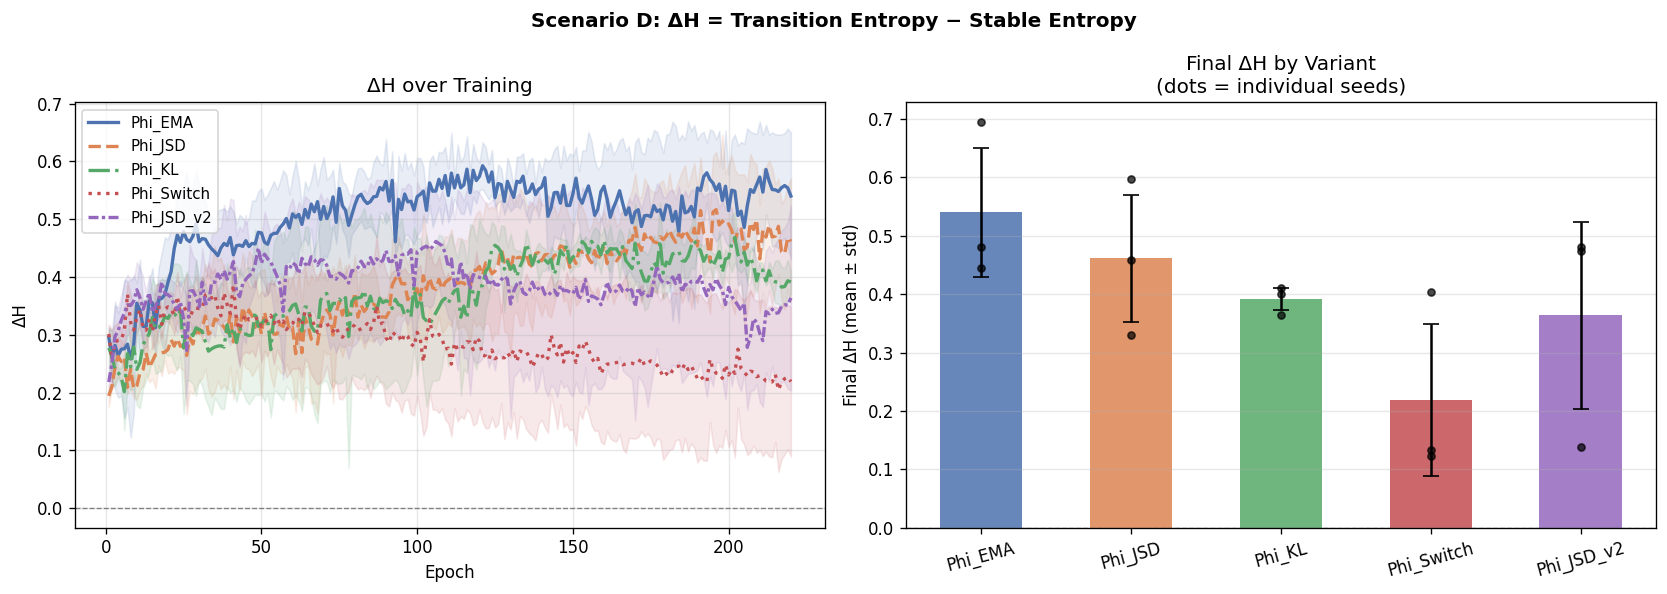

Figure saved: scenario_D_delta_H.png


In [ ]:
# ============================================================
# STEP 11: ΔH trajectory + final bar chart (논문 figure candidate)
# ============================================================

fig, (ax_line, ax_bar) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Scenario D: ΔH = Transition Entropy − Stable Entropy',
             fontsize=12, fontweight='bold')

for phi_name in PHI_VARIANTS:
    curves = np.array([
        np.array(all_results[phi_name][s]['test_transition_entropy'])
        - np.array(all_results[phi_name][s]['test_stable_entropy'])
        for s in SEEDS
    ])
    mean_c = curves.mean(axis=0); std_c = curves.std(axis=0)
    epochs = np.arange(1, len(mean_c) + 1)
    ax_line.plot(epochs, mean_c,
                 color=COLORS[phi_name], ls=LINESTYLES[phi_name],
                 linewidth=2.0, label=phi_name)
    ax_line.fill_between(epochs, mean_c - std_c, mean_c + std_c,
                          color=COLORS[phi_name], alpha=0.12)

ax_line.axhline(0, color='gray', lw=0.8, ls='--')
ax_line.set_xlabel('Epoch'); ax_line.set_ylabel('ΔH')
ax_line.set_title('ΔH over Training')
ax_line.legend(fontsize=9); ax_line.grid(alpha=0.3)

bar_x = np.arange(len(PHI_VARIANTS))
bar_means, bar_stds = [], []
for phi_name in PHI_VARIANTS:
    vals = [all_results[phi_name][s]['test_transition_entropy'][-1]
            - all_results[phi_name][s]['test_stable_entropy'][-1] for s in SEEDS]
    bar_means.append(np.mean(vals)); bar_stds.append(np.std(vals))

ax_bar.bar(bar_x, bar_means, yerr=bar_stds, capsize=5,
           color=[COLORS[n] for n in PHI_VARIANTS], alpha=0.85, width=0.55)
for i, phi_name in enumerate(PHI_VARIANTS):
    for s in SEEDS:
        dh = (all_results[phi_name][s]['test_transition_entropy'][-1]
              - all_results[phi_name][s]['test_stable_entropy'][-1])
        ax_bar.scatter(i, dh, color='black', s=18, zorder=5, alpha=0.7)

ax_bar.set_xticks(bar_x); ax_bar.set_xticklabels(PHI_VARIANTS, rotation=15)
ax_bar.set_ylabel('Final ΔH (mean ± std)')
ax_bar.set_title('Final ΔH by Variant\n(dots = individual seeds)')
ax_bar.axhline(0, color='gray', lw=0.8, ls='--'); ax_bar.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('scenario_D_delta_H.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: scenario_D_delta_H.png')


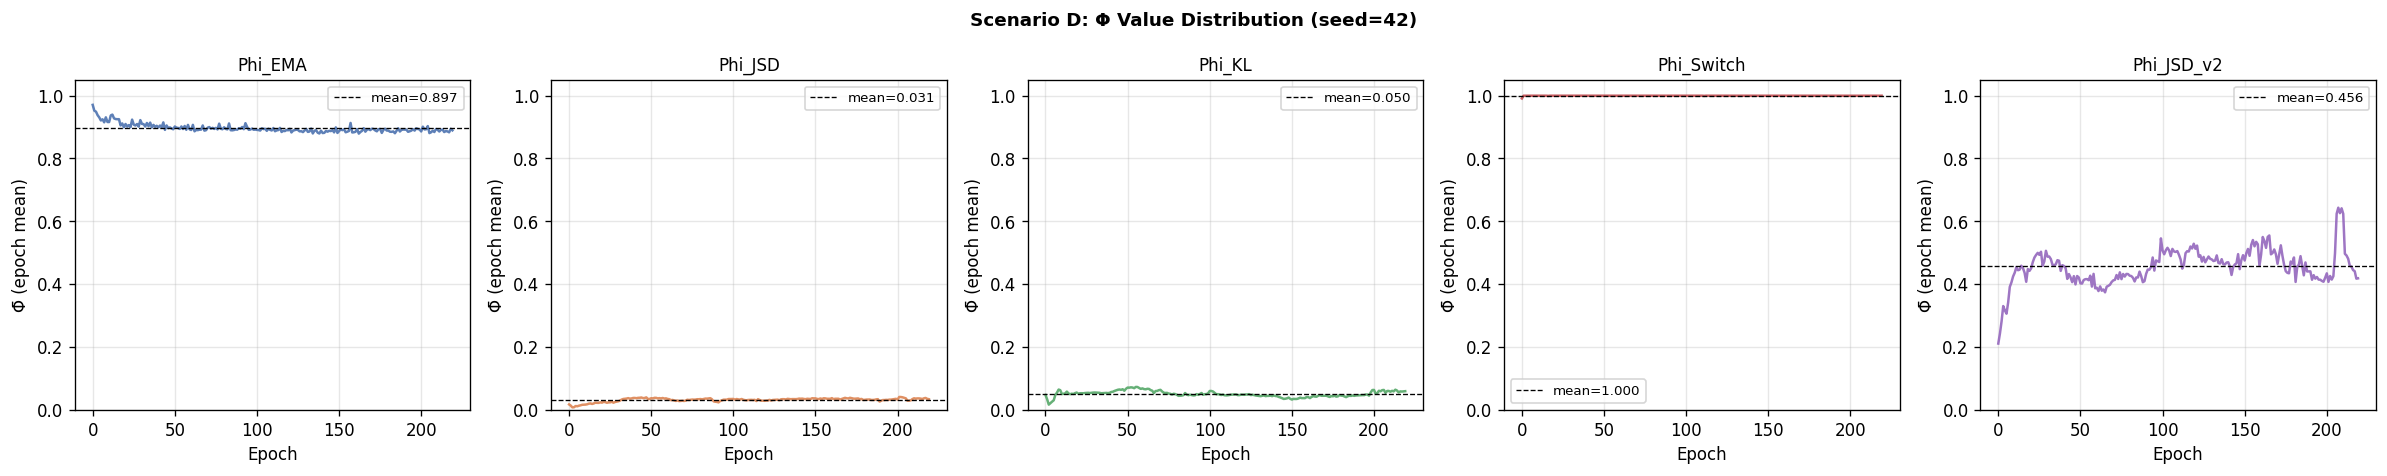

Figure saved: scenario_D_phi_trace.png


In [ ]:
# ============================================================
# STEP 12: Φ 신호 분포 비교
# ============================================================

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=False)
fig.suptitle('Scenario D: Φ Value Distribution (seed=42)', fontsize=11, fontweight='bold')

for ax, phi_name in zip(axes, PHI_VARIANTS):
    phi_curve = np.array(all_results[phi_name][42]['phi_values'])
    ax.plot(phi_curve, color=COLORS[phi_name], linewidth=1.5, alpha=0.9)
    ax.axhline(phi_curve.mean(), color='black', lw=0.8, ls='--',
                label=f'mean={phi_curve.mean():.3f}')
    ax.set_title(phi_name, fontsize=10)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Φ̄ (epoch mean)')
    ax.set_ylim(0, 1.05); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('scenario_D_phi_trace.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: scenario_D_phi_trace.png')


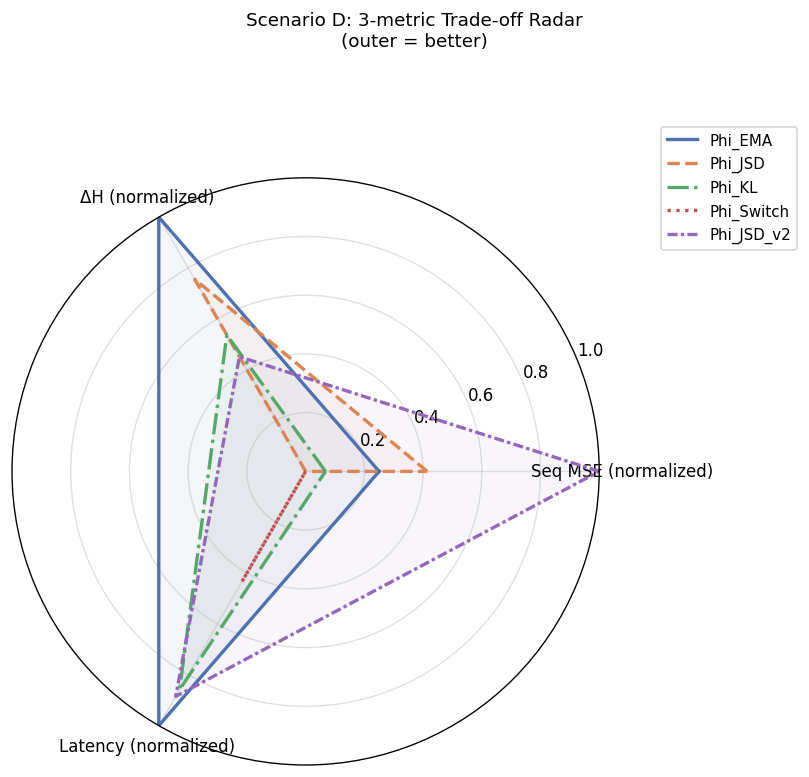

Figure saved: scenario_D_radar.png


In [ ]:
# ============================================================
# STEP 13: 3-metric Radar Chart (논문 시각화 candidate)
# ============================================================

metrics = ['Seq MSE (normalized)', 'ΔH (normalized)', 'Latency (normalized)']
N = len(metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

raw = {}
for phi_name in PHI_VARIANTS:
    mse_vals = [all_results[phi_name][s]['test_seq_mse'][-1] for s in SEEDS]
    dh_vals  = [(all_results[phi_name][s]['test_transition_entropy'][-1]
                 - all_results[phi_name][s]['test_stable_entropy'][-1]) for s in SEEDS]
    lat_vals = [(all_results[phi_name][s]['test_switch_latency'][-1]
                 if not math.isnan(all_results[phi_name][s]['test_switch_latency'][-1]) else 0.0)
                for s in SEEDS]
    raw[phi_name] = [np.mean(mse_vals), np.mean(dh_vals), np.mean(lat_vals)]

all_mse = [raw[n][0] for n in PHI_VARIANTS]
all_dh  = [raw[n][1] for n in PHI_VARIANTS]
all_lat = [raw[n][2] for n in PHI_VARIANTS]
mse_range = max(all_mse) - min(all_mse) + 1e-8
dh_range  = max(all_dh)  - min(all_dh)  + 1e-8
lat_range = max(all_lat) - min(all_lat) + 1e-8

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
fig.suptitle('Scenario D: 3-metric Trade-off Radar\n(outer = better)', fontsize=11)

for phi_name in PHI_VARIANTS:
    values = [
        1.0 - (raw[phi_name][0] - min(all_mse)) / mse_range,
              (raw[phi_name][1] - min(all_dh))  / dh_range,
        1.0 - (raw[phi_name][2] - min(all_lat)) / lat_range,
    ]
    values += values[:1]
    ax.plot(angles, values, color=COLORS[phi_name], ls=LINESTYLES[phi_name],
             linewidth=2, label=phi_name)
    ax.fill(angles, values, color=COLORS[phi_name], alpha=0.06)

ax.set_thetagrids(np.degrees(angles[:-1]), metrics)
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('scenario_D_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: scenario_D_radar.png')


In [ ]:
# ============================================================
# STEP 14: 논문용 상세 테이블 — per-seed + 평균
# ============================================================

rows = []
for phi_name in PHI_VARIANTS:
    for seed in SEEDS:
        logs = all_results[phi_name][seed]
        final_mse = logs['test_seq_mse'][-1]
        final_s   = logs['test_stable_entropy'][-1]
        final_t   = logs['test_transition_entropy'][-1]
        final_lat = logs['test_switch_latency'][-1]
        final_lat = final_lat if not math.isnan(final_lat) else -1
        rows.append({
            'Phi': phi_name, 'Seed': seed,
            'Seq MSE': final_mse, 'Stable Ent': final_s,
            'Trans Ent': final_t, 'ΔH': final_t - final_s,
            'Switch Lat': final_lat,
        })

df_detail = pd.DataFrame(rows)
print('\n=== Per-seed Results ===')
print(df_detail.to_string(float_format=lambda x: f'{x:.4f}', index=False))

print('\n=== Aggregated (mean ± std) ===')
agg = df_detail.groupby('Phi')[['Seq MSE', 'ΔH', 'Switch Lat']].agg(['mean', 'std'])
print(agg.to_string(float_format=lambda x: f'{x:.4f}'))

print('\n=== Paper-ready Table ===')
print(f'{"Phi Variant":<16} {"Seq MSE":>16} {"ΔH":>16} {"Latency":>16}')
print('-' * 64)
for phi_name in PHI_VARIANTS:
    sub = df_detail[df_detail['Phi'] == phi_name]
    mse_str = f"{sub['Seq MSE'].mean():.3f} ± {sub['Seq MSE'].std():.3f}"
    dh_str  = f"{sub['ΔH'].mean():.3f} ± {sub['ΔH'].std():.3f}"
    lat_str = f"{sub['Switch Lat'].mean():.3f} ± {sub['Switch Lat'].std():.3f}"
    print(f'{phi_name:<16} {mse_str:>16} {dh_str:>16} {lat_str:>16}')



=== Per-seed Results ===
       Phi  Seed  Seq MSE  Stable Ent  Trans Ent     ΔH  Switch Lat
   Phi_EMA    42   0.2560      0.3626     0.8436 0.4811      0.0000
   Phi_EMA   123   0.3127      0.3723     0.8172 0.4449      0.2778
   Phi_EMA   456   0.2457      0.1572     0.8516 0.6943      0.8611
   Phi_JSD    42   0.2709      0.4410     0.8997 0.4587      1.3611
   Phi_JSD   123   0.2593      0.3185     0.9150 0.5965      1.1944
   Phi_JSD   456   0.2558      0.6626     0.9926 0.3300      1.7222
    Phi_KL    42   0.4170      0.4824     0.8922 0.4098      1.4167
    Phi_KL   123   0.2913      0.5407     0.9402 0.3995      0.1389
    Phi_KL   456   0.1377      0.5312     0.8961 0.3649      0.0278
Phi_Switch    42   0.2338      0.8103     0.9323 0.1220      1.3611
Phi_Switch   123   0.2886      0.4805     0.8836 0.4031      0.7222
Phi_Switch   456   0.3354      0.7682     0.9009 0.1327      0.8333
Phi_JSD_v2    42   0.2399      0.3807     0.8547 0.4740      1.2778
Phi_JSD_v2   123   0.2

In [ ]:
# ============================================================
# STEP 15: 이론적 해석 자동 출력 (v2: Phi_JSD_v2 분기 포함)
# ============================================================

print('\n' + '='*72)
print('SCENARIO D v2 — THEORETICAL INTERPRETATION')
print('='*72)

final_summary = {}
for phi_name in PHI_VARIANTS:
    mse_vals = [all_results[phi_name][s]['test_seq_mse'][-1] for s in SEEDS]
    dh_vals  = [(all_results[phi_name][s]['test_transition_entropy'][-1]
                 - all_results[phi_name][s]['test_stable_entropy'][-1]) for s in SEEDS]
    final_summary[phi_name] = {'mse': np.mean(mse_vals), 'dh': np.mean(dh_vals)}

best_mse_name = min(final_summary, key=lambda n: final_summary[n]['mse'])
best_dh_name  = max(final_summary, key=lambda n: final_summary[n]['dh'])

print(f'\nBest Seq MSE : {best_mse_name} ({final_summary[best_mse_name]["mse"]:.4f})')
print(f'Best ΔH      : {best_dh_name}  ({final_summary[best_dh_name]["dh"]:.4f})')

# v2 핵심 비교: Phi_JSD_v2 vs Phi_EMA
jsd_v2_dh  = final_summary.get('Phi_JSD_v2', {}).get('dh', float('nan'))
ema_dh     = final_summary.get('Phi_EMA',    {}).get('dh', float('nan'))
jsd_v2_mse = final_summary.get('Phi_JSD_v2', {}).get('mse', float('nan'))
ema_mse    = final_summary.get('Phi_EMA',    {}).get('mse', float('nan'))

print(f'\n--- Phi_JSD_v2 vs Phi_EMA (v2 핵심 비교) ---')
print(f'  ΔH    : JSD_v2={jsd_v2_dh:.4f}  EMA={ema_dh:.4f}  diff={jsd_v2_dh-ema_dh:+.4f}')
print(f'  SeqMSE: JSD_v2={jsd_v2_mse:.4f}  EMA={ema_mse:.4f}  diff={jsd_v2_mse-ema_mse:+.4f}')

print('\n--- Implication for Theory_and_Axioms.md §Φ ---')

if best_dh_name == 'Phi_JSD_v2':
    print("""
[RESULT: Phi_JSD_v2 wins on ΔH — v2 가설 검증 성공]
  → per-sample JSD std 항이 fixation 국면에서도 nonzero Φ를 유지함.
  → '라우팅 heterogeneity as switching pressure' 실증적 근거 확보.

  Theory §Φ 업데이트 제안:
    'Φ의 핵심 기능은 gate 분포의 시간적 변화(JSD_v1)가 아니라
     현재 배치 내 routing confidence의 heterogeneity(JSD_v2)이다.
     std_i[JSD(g_i || ḡ_t)]는 fixation 달성 후에도 샘플 간 라우팅
     불확실성이 존재하는 한 nonzero를 유지하며,
     DwellTimeRegularizer와 상호작용하여 ΔH를 강화한다.'

  arXiv v2: §5.3 Limitation 'Φ theoretical grounding partial' 해소 가능.
  → per-sample routing heterogeneity as information-theoretic Φ proxy.
""")
elif best_dh_name == 'Phi_EMA':
    print("""
[RESULT: Phi_EMA still wins — JSD_v2도 EMA composite을 넘지 못함]
  → std(per-sample JSD)가 gap_t 항을 대체하지 못함.
  → 핵심 원인 분석:
     gap_t = ReLU(err_top1 - err_best): fixation 국면에서도
     현재 routing의 설명력 부족을 직접 측정 (task-aware)
     std(JSD_i): routing noise 측정 (task-agnostic)
     두 신호는 근본적으로 다른 정보를 운반.

  Theory §Φ 결론 (확정):
    'Φ의 필수 구성 요소는 (1) 환경 변화 감지(Δx_env)와
     (2) 현재 routing의 task-level 설명력 부족(gap_t + L_task)의 결합이다.
     순수 information-geometric 접근(JSD류)은 설명력 부족 채널을 갖지 못해
     fixation 국면에서 신호가 소멸한다는 구조적 한계를 가진다.
     이 결과는 EMA composite Φ 설계의 사후 실증적 정당화를 제공한다.'

  → §5.3: Limitation → Contribution으로 전환 가능한 지점.
""")
elif best_dh_name in ('Phi_JSD', 'Phi_KL'):
    print("""
[RESULT: v1 JSD/KL wins — v2 수정이 오히려 악화]
  → std(per-sample JSD)가 과도한 노이즈를 주입했을 가능성.
  → s_div 하이퍼파라미터 재조정 또는 EMA decay 강화 (0.90~0.95) 권고.
""")
elif best_dh_name == 'Phi_Switch':
    print("""
[RESULT: PolicyNet-learned Φ wins]
  → 예비 시나리오 RL 도입의 근거 강화.
""")

print()
print('Figures: scenario_D_learning_curves.png, scenario_D_delta_H.png,')
print('         scenario_D_phi_trace.png, scenario_D_radar.png')



SCENARIO D v2 — THEORETICAL INTERPRETATION

Best Seq MSE : Phi_JSD_v2 (0.2282)
Best ΔH      : Phi_EMA  (0.5401)

--- Phi_JSD_v2 vs Phi_EMA (v2 핵심 비교) ---
  ΔH    : JSD_v2=0.3639  EMA=0.5401  diff=-0.1762
  SeqMSE: JSD_v2=0.2282  EMA=0.2715  diff=-0.0433

--- Implication for Theory_and_Axioms.md §Φ ---

[RESULT: Phi_EMA still wins — JSD_v2도 EMA composite을 넘지 못함]
  → std(per-sample JSD)가 gap_t 항을 대체하지 못함.
  → 핵심 원인 분석:
     gap_t = ReLU(err_top1 - err_best): fixation 국면에서도
     현재 routing의 설명력 부족을 직접 측정 (task-aware)
     std(JSD_i): routing noise 측정 (task-agnostic)
     두 신호는 근본적으로 다른 정보를 운반.

  Theory §Φ 결론 (확정):
    'Φ의 필수 구성 요소는 (1) 환경 변화 감지(Δx_env)와
     (2) 현재 routing의 task-level 설명력 부족(gap_t + L_task)의 결합이다.
     순수 information-geometric 접근(JSD류)은 설명력 부족 채널을 갖지 못해
     fixation 국면에서 신호가 소멸한다는 구조적 한계를 가진다.
     이 결과는 EMA composite Φ 설계의 사후 실증적 정당화를 제공한다.'

  → §5.3: Limitation → Contribution으로 전환 가능한 지점.


Figures: scenario_D_learning_curves.png, scenario_D_delta_H.png,
         sc

In [ ]:
# ============================================================
# STEP 16: 결과 저장
# ============================================================
import json, shutil
import os

# Drive 마운트
from google.colab import drive
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/nomadic_intelligence/scenario_D'

os.makedirs(SAVE_DIR, exist_ok=True)

if 'df_detail' in locals():
    df_detail.to_csv(os.path.join(SAVE_DIR, 'results_per_seed.csv'), index=False)
if 'df' in locals():
    df.to_csv(os.path.join(SAVE_DIR, 'results_summary.csv'))

serializable = {}
for phi_name in PHI_VARIANTS:
    serializable[phi_name] = {}
    for seed in SEEDS:
        serializable[phi_name][str(seed)] = {
            k: [float(x) for x in v]
            for k, v in all_results[phi_name][seed].items()
        }

with open(os.path.join(SAVE_DIR, 'all_logs.json'), 'w') as f:
    json.dump(serializable, f, indent=2)

for fname in ['scenario_D_learning_curves.png', 'scenario_D_delta_H.png',
               'scenario_D_phi_trace.png', 'scenario_D_radar.png']:
    src = f'/content/{fname}'
    if os.path.exists(src):
        shutil.copy(src, os.path.join(SAVE_DIR, fname))

print(f'Results saved to: {SAVE_DIR}')
for f in sorted(os.listdir(SAVE_DIR)):
    print(f'  {f}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


NameError: name 'PHI_VARIANTS' is not defined